In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [160]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [161]:
x,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1, noise=20)

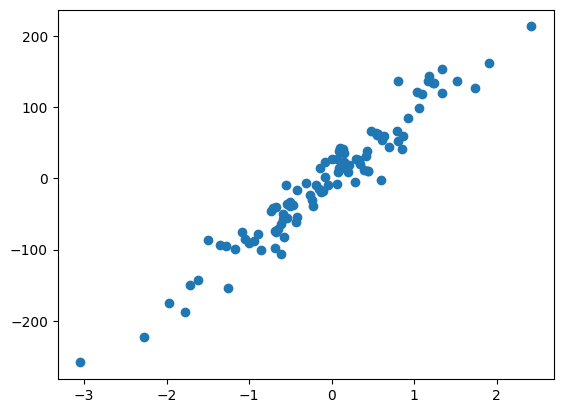

In [162]:
plt.scatter(x,y);

In [163]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=50)

In [164]:
lr = LinearRegression()

lr.fit(x_train,y_train)
y_pred = (lr.predict(x_test))

lr.coef_, lr.intercept_

(array([91.47527266]), np.float64(1.1998460977815482))

In [165]:
r2_score(y_test,y_pred)

0.9656477458978192

# making own GDR Regressor

In [166]:
class ChazGDRegressor:
    
    def __init__(self, rate, epochs):
        self.m = 1
        self.c = 0
        self.rate = rate
        self.epochs = epochs
        
    def fit(self,x_train,y_train):
        for i in range(self.epochs):
            loss_slope_c = (-2) * np.sum(y_train - (self.m*x_train).ravel() - self.c)
            loss_slope_m = (-2) * np.sum((y_train - (self.m*x_train).ravel() - self.c)*x_train.ravel())
            self.c = self.c - (self.rate*loss_slope_c)
            self.m = self.m - (self.rate*loss_slope_m)
        return f"gdr : c= {self.c}, m= {self.m}"
    
    def predict(self,x_test):
        return self.m*x_test + self.c

In [167]:
gdr = ChazGDRegressor(0.001,100)

print(gdr.fit(x_train,y_train))
print(f"original : c= {lr.intercept_}, m= {lr.coef_}")

gdr : c= 1.1998093961341962, m= 91.47516714425157
original : c= 1.1998460977815482, m= [91.47527266]


In [168]:
y_pred = gdr.predict(x_test)

In [169]:
r2_score(y_test,y_pred)

0.9656478000128371